In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Loading the dataset
df_retail = pd.read_csv('../data/q3_retail_promotions.csv')

In [2]:
# 1. Date Feature Engineering
# Ensuring the date column is in the right format
df_retail['transaction_date'] = pd.to_datetime(df_retail['transaction_date'])

# Extracting basic components
df_retail['year'] = df_retail['transaction_date'].dt.year
df_retail['month'] = df_retail['transaction_date'].dt.month
df_retail['day_of_week'] = df_retail['transaction_date'].dt.dayofweek

# Creating the binary 'is_month_end' feature (True for 25th onwards)
df_retail['is_month_end'] = (df_retail['transaction_date'].dt.day >= 25).astype(int)

# Quick check of the new columns
df_retail[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


In [3]:
# 2. Temporal Train-Test Split
# First, we must sort the data by date to maintain chronological order
df_retail = df_retail.sort_values(by='transaction_date')

# Defining features (X) and target (y)
X = df_retail.drop(columns=['transaction_date', 'items_sold', 'store_id']) # store_id is usually just an ID
y = df_retail['items_sold']

# Calculating the 80/20 split point
split_idx = int(len(df_retail) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} records | Testing on {len(X_test)} records")

Training on 960 records | Testing on 240 records


In [4]:
# 3. Preprocessing Pipeline
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = X.columns.drop(cat_features).tolist()

# Defining the processor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Creating separate pipelines for the two models
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

# Fitting models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

[Linear Regression] RMSE: 27.13 | MAE: 21.07
[Random Forest] RMSE: 31.12 | MAE: 25.00


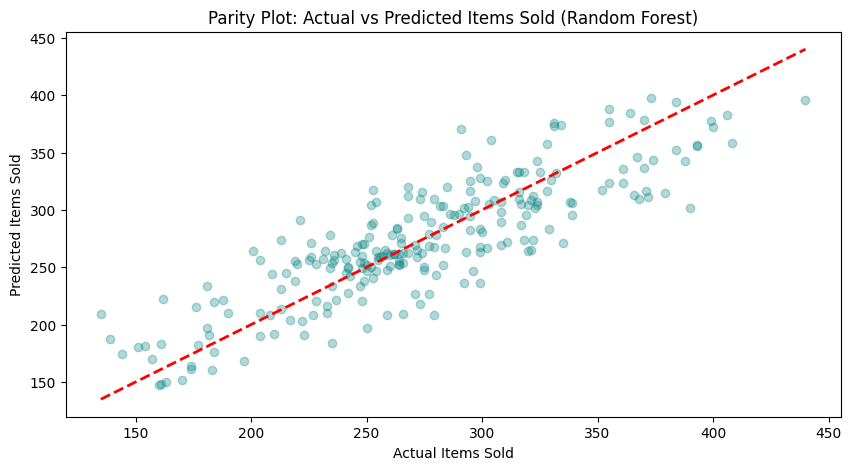

In [5]:
# 4. Model Training and Evaluation
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metric Reporting
def get_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{model_name}] RMSE: {rmse:.2f} | MAE: {mae:.2f}")

get_metrics(y_test, y_pred_lr, "Linear Regression")
get_metrics(y_test, y_pred_rf, "Random Forest")

# Parity Plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Parity Plot: Actual vs Predicted Items Sold (Random Forest)")
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.show()

In [6]:
# Identifying Top 5 Influential Features
# Extracting feature names after encoding
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1]
encoded_names = list(cat_encoder.get_feature_names_out(cat_features))
all_features = num_features + encoded_names

importances = rf_pipeline.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

print("Top 5 Influential Features:")
print(importance_df.head(5))

Top 5 Influential Features:
                feature  importance
1           is_festival    0.173557
17     store_size_small    0.168355
14  location_type_urban    0.108331
5           day_of_week    0.095854
2   competition_density    0.063912
